In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: c:\Users\xanti\OneDrive\Documents\LAB03_AD\Analitica-Datos


In [3]:
from analytics import extract, transform, segment
import pandas as pd

df = extract.construir_dataset_base(extract.cargar_olist("data/raw"))
df = transform.agregar_features_fecha(df)

pedidos = df[["customer_unique_id", "order_purchase_timestamp", "precio_total"]].rename(
    columns={"precio_total": "monto_pedido"}
)
fecha_referencia = pedidos["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm = segment.calcular_rfm(pedidos, fecha_referencia)
rfm.head()

orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)
payments: (103886, 5)
reviews: (99224, 7)


,customer_unique_id,recencia,frecuencia,monto
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,18.90
2,0000f46a3911fa3c0805444483337064,586,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,337,1,180.00


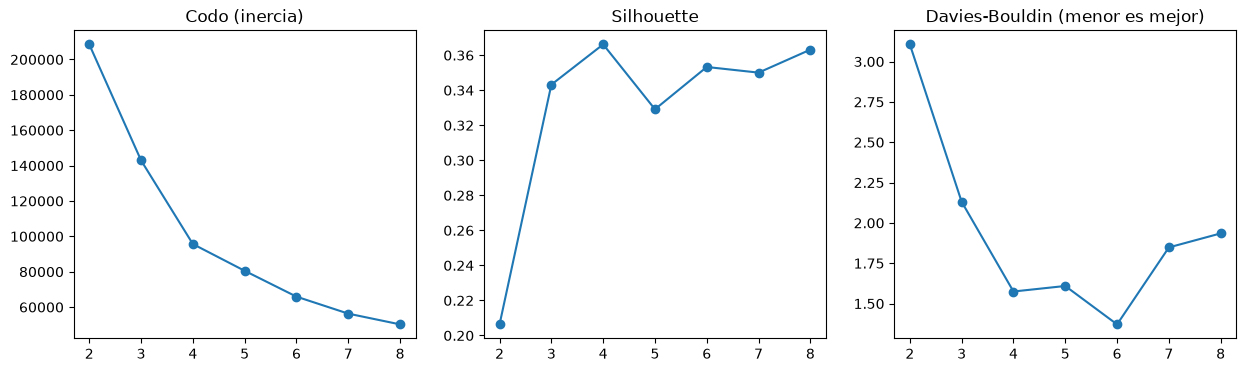

In [ ]:
import matplotlib.pyplot as plt

X = rfm[["recencia", "frecuencia", "monto"]]
inercias, sils, dbs = [], [], []

for k in range(2, 9):
    pipeline = segment.entrenar_pipeline_clustering(X, n_clusters=k)
    labels = pipeline.predict(X)
    inercias.append(pipeline.named_steps["modelo"].inertia_)
    metricas = segment.evaluar_clustering(X, labels)
    sils.append(metricas["silhouette"])
    dbs.append(metricas["davies_bouldin"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(2, 9), inercias, marker="o")
axes[0].set_title("Codo (inercia)")

axes[1].plot(range(2, 9), sils, marker="o")
axes[1].set_title("Silhouette")

axes[2].plot(range(2, 9), dbs, marker="o")
axes[2].set_title("Davies-Bouldin (menor es mejor)")
plt.show()

MArkdown con respuesta xd

In [6]:
K_ELEGIDO = 4  # ajusta según lo que veas en la celda anterior
pipeline_final = segment.entrenar_pipeline_clustering(X, n_clusters=K_ELEGIDO)
rfm["segmento"] = pipeline_final.predict(X)

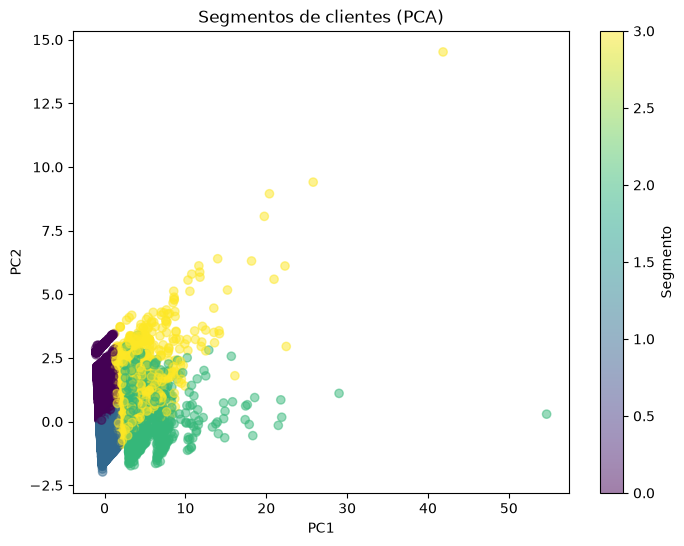

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rfm["segmento"], cmap="viridis", alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Segmentos de clientes (PCA)")
plt.colorbar(label="Segmento")
plt.show()

In [8]:
perfil = segment.perfilar_segmentos(
    rfm, columna_segmento="segmento", columnas_perfil=["recencia", "frecuencia", "monto"]
)
print(perfil)

rfm.to_csv("data/processed/clientes_segmentados.csv", index=False)

            recencia  frecuencia        monto  n_clientes
segmento                                                 
0         438.758066    1.000000   112.789920       38713
1         178.383495    1.000000   113.194685       52131
2         269.210935    2.116436   239.419676        2963
3         289.961555    1.016164  1142.356894        2289
